In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# De Relaciones Lineales a Computer Vision

# Jugar con el Dataset de fashion_mnist

In [5]:
# Cargar Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
# X_train       y_train         X_test          y_test
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Sanity Check
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


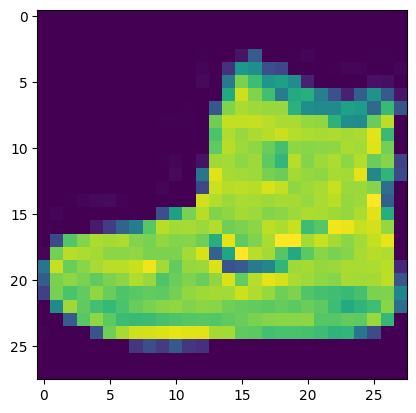

In [9]:
# Dibujar la primera imagen y comprobar
plt.figure()
plt.imshow(train_images[0])
plt.grid(False)
plt.show()

In [10]:
# Normalizar -> No es necesario pero funciona mejor, llega a converger de manera más sencilla

train_images = train_images / 255.0
test_images = test_images / 255.0

In [20]:
# Construir nuestra Red

# OJOOO !!! Activación -> SOFTMAX en dataset de clasificación

#Creamos el modelo con 3 capas
#128, 64, 10 (La última capa con las neuronas = etiquetas)

model = tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=(28, 28)),
                                    tf.keras.layers.Dense(128, activation="relu"),
                                    tf.keras.layers.Dense(64, activation="relu"),
                                    tf.keras.layers.Dense(10, activation="softmax")])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# 784*128+128
# 128*64+64
# 64*10+10

In [23]:
# Compilar

# Función de Perdida -> sparse_categorial_crossentropy
# Optimizador -> Adam
# MEtrica -> Accuaracy

# IMPORTANTE categorical_crossentropy -> Cuando las y estan en one_hot_encoding cuando no sparse_categorial_crossentropy

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [24]:
# Entrenar

model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7821 - loss: 0.6217
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8647 - loss: 0.3727
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8793 - loss: 0.3285
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8837 - loss: 0.3089
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8886 - loss: 0.3005
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8977 - loss: 0.2748
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9043 - loss: 0.2595
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9053 - loss: 0.2481
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9098 - loss: 0.2435
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9101 - loss: 0.2389


In [25]:
# Jugando con el Metodo evaluate, predict, cambiando el número de capas, cambiando el optimizador, añadir más capas intermedias

test_loss, test_acc = model.evaluate(test_images, test_labels)
print(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8850 - loss: 0.3334
0.8847000002861023


In [ ]:
# Callbacks